# Analysing the results of iGUESSMD

In this notebook, we will examine the results of a set of iGUESSMD simulations performed to examine the helix-to-coil transition of deca-alanine. By default, we will use a set of example data generated using the [iGUESSMD simulation tutorial](https://github.com/IRL2/nanover-server-py/tree/main/tutorials/5.%20iGUESSMD/analysis.ipynb) notebook. If you want to use data you generated using this notebook, replace the relevant iGUESSMD output directories

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import nanover.iguessmd.analysis as analysis

# Define iGUESSMD data directory and general iGUESSMD data filename
iguessmd_data_dir = "../systems/iguessmd/outputs/iguessmd_output"
general_iguessmd_data_filename = "general_iguessmd_data.npy"

# Define path to general iGUESSMD data file
general_iguessmd_data_file = f"{iguessmd_data_dir}/{general_iguessmd_data_filename}"

# Retrieve iGUESSMD data files and sort according to index
iguessmd_data_files = [f"{iguessmd_data_dir}/{f}" for f in os.listdir(iguessmd_data_dir) if f.startswith("deca-alanine") and f.endswith(".npy")]
iguessmd_data_files.sort()
iguessmd_data_files.sort(key=len)

## Loading the data

The first thing to do is to load the general data associated with the iGUESSMD simulations, which the `analysis` module contains a function to do.

In [2]:
iguessmd_general_data = analysis.load_general_iguessmd_data(general_iguessmd_data_file)
iguessmd_general_data.keys()

dict_keys(['iguessmd_atom_indices', 'iguessmd_path', 'iguessmd_force_constant', 'temperature', 'timestep_ps'])

Now we want to load the data from the individual iGUESSMD simulations. These files contain
- the work done across the iGUESSMD simulation
- the positions of the atom(s) to which the iGUESSMD force was applied

We will load these data into separate numpy arrays for analysis

In [3]:
atom_coord_arrays = np.zeros((len(iguessmd_data_files), *iguessmd_general_data['iguessmd_path'].shape))
work_arrays = np.zeros((len(iguessmd_data_files), iguessmd_general_data['iguessmd_path'].shape[0]))

for idx, file in enumerate(iguessmd_data_files):
    with open(file, 'rb') as infile:
        atom_coord_arrays[idx, :] = np.load(infile)
        work_arrays[idx, :] = np.load(infile)

## Work profiles and PMFs

Now we can start to calculate and plot quantities using these data. First, let's take a look at the work profiles generated during the iGUESSMD simulations. We'll plot them as a function of the reaction coordinate $\xi$ value, which corresponds to the distance travelled along the reaction path.

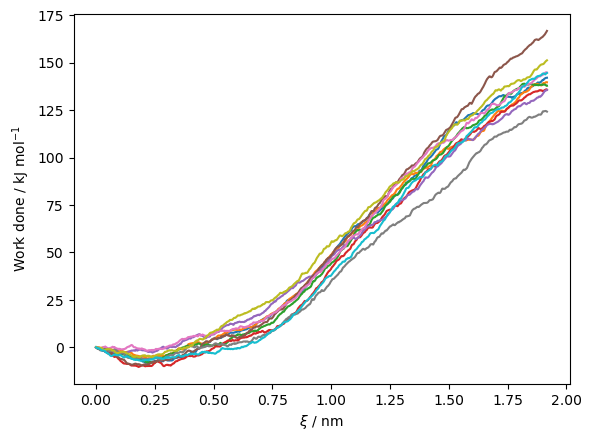

In [4]:
rc_value = analysis.calculate_distance_along_reaction_coordinate(iguessmd_general_data['iguessmd_path'])

plt.plot(rc_value, np.transpose(work_arrays))
plt.xlabel(r"$\xi$ / nm")
plt.ylabel(r"Work done / kJ mol$^{-1}$")
plt.show()

Next, let's calculate the PMF associated with these work profiles. We'll do this in two ways, and compare the results:
- Using the second cumulant approximation
- Using the exponential average formula

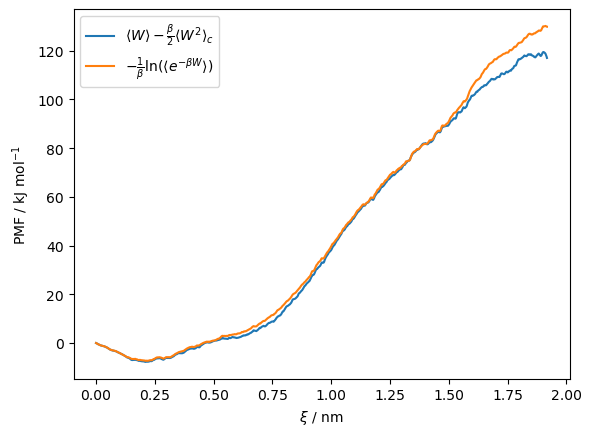

In [5]:
pmf_second_cumulant = analysis.calculate_pmf_second_cumulant_kJ_mol(work_done_array_kJ_mol=work_arrays, temperature_K=iguessmd_general_data['temperature'])
pmf_exp_avg = analysis.calculate_pmf_exponential_average_kJ_mol(work_done_array_kJ_mol=work_arrays, temperature_K=iguessmd_general_data['temperature'])

plt.plot(rc_value, pmf_second_cumulant, label=r"$\langle W \rangle - \frac{\beta}{2}\langle W^{2} \rangle_{c}$")
plt.plot(rc_value, pmf_exp_avg, label=r"$-\frac{1}{\beta} \ln ( \langle e^{-\beta W} \rangle )$")
plt.xlabel(r"$\xi$ / nm")
plt.ylabel(r"PMF / kJ mol$^{-1}$")
plt.legend()
plt.show()

Now we'll plot these PMFs as a function of end-to-end distance $d_{\mathrm{NN}}$ between the restrained N atom and the constrained N atom. To do this we'll need the coordinate of the constrained N atom, which we can retrieve from the deca-alanine NanoVer OpenMM XML input file. We'll also compare the PMFs plotted this way to the true (converged) PMF, calculated using data from [INSERT PAPER CITATION HERE].

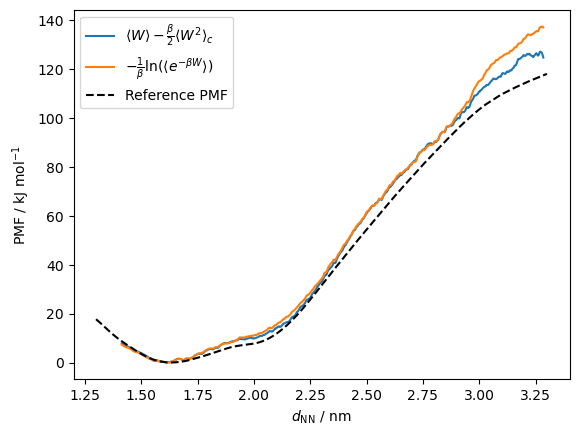

In [6]:
from nanover.iguessmd.openmm import OMMiGUESSMDSimulation

# Determine position of constrained atom
iguessmd_sim = OMMiGUESSMDSimulation.from_xml_path(path="../systems/openmm/deca-alanine_constrained.xml",
                                                   iguessmd_atom_indices=iguessmd_general_data['iguessmd_atom_indices'],
                                                   iguessmd_path=iguessmd_general_data['iguessmd_path'],
                                                   iguessmd_force_constant=iguessmd_general_data['iguessmd_force_constant'])

r_constrained_atom = iguessmd_sim.simulation.context.getState(getPositions=True).getPositions(asNumpy=True)[6]._value

# Calculate end-to-end distance
end_to_end_dist = np.linalg.norm(iguessmd_general_data['iguessmd_path'] - r_constrained_atom, axis=1)

# Load reference data
ref_data = dict(np.load("../systems/iguessmd/reference_data/deca-alanine_reference_data.npz"))

# Plot PMFs
plt.plot(end_to_end_dist, pmf_second_cumulant - np.min(pmf_second_cumulant), label=r"$\langle W \rangle - \frac{\beta}{2}\langle W^{2} \rangle_{c}$")
plt.plot(end_to_end_dist, pmf_exp_avg - np.min(pmf_exp_avg), label=r"$-\frac{1}{\beta} \ln ( \langle e^{-\beta W} \rangle )$")
plt.plot(ref_data['ref_end_to_end_dist'], ref_data['ref_pmf_second_cumulant'] - np.min(ref_data['ref_pmf_second_cumulant']), label="Reference PMF", color='black', linestyle='dashed')
plt.xlabel(r"$d_{\mathrm{NN}}$ / nm")
plt.ylabel(r"PMF / kJ mol$^{-1}$")
plt.legend()
plt.show()

## Reducing size of working data

Sometimes, it may be difficult to work with the full arrays of data from a large set of iGUESSMD calculations: we may wish to reduce the size of our dataset.

We can choose to perform the same analysis as above, but with every $n^{\mathrm{th}}$ data point to reduce the size of the objects we create. This can be achieved either by passing an integer defining the desired value of $n$ to the `every_nth` field of the functions for which this is an option, or via the `get_every_nth` function. We can also optionally include the final point (which may be useful if the we want the final free energy difference between the initial and final configurations, for example), if the $n$ is not a factor of $n_{\mathrm{tot}} - 1$, where $n_{\mathrm{tot}}$ is the total length of the data arrays output when saving the iGUESSMD simulations. This is demonstrated below:

In [ ]:
from nanover.iguessmd.utils import get_every_nth

# Define n for every_nth
every_nth = 100

# Create reduced versions of arrays using every_nth option
reduced_rc_value = analysis.calculate_distance_along_reaction_coordinate(iguessmd_general_data['iguessmd_path'], every_nth_point=every_nth, include_end_point=False)

# Create reduced version of arrays using get_every_nth
reduced_end_to_end_dist = get_every_nth(array=end_to_end_dist, axis=0, every_nth=every_nth, include_end=False)
reduced_work_arrays = get_every_nth(array=work_arrays, axis=1, every_nth=every_nth, include_end=False)
reduced_pmf_second_cumulant = get_every_nth(array=pmf_second_cumulant, axis=0, every_nth=every_nth, include_end=False)
reduced_pmf_exp_avg = get_every_nth(array=pmf_exp_avg, axis=0, every_nth=every_nth, include_end=False)

# Plot reduced work arrays
plt.plot(reduced_rc_value, np.transpose(reduced_work_arrays))
plt.xlabel(r"$\xi$ / nm")
plt.ylabel(r"Work done / kJ mol$^{-1}$")
plt.show()

# Plot reduced PMFs
plt.plot(reduced_end_to_end_dist, reduced_pmf_second_cumulant - np.min(reduced_pmf_second_cumulant), label=r"$\langle W \rangle - \frac{\beta}{2}\langle W^{2} \rangle_{c}$")
plt.plot(reduced_end_to_end_dist, reduced_pmf_exp_avg - np.min(reduced_pmf_exp_avg), label=r"$-\frac{1}{\beta} \ln ( \langle e^{-\beta W} \rangle )$")
plt.plot(ref_data['ref_end_to_end_dist'], ref_data['ref_pmf_second_cumulant'] - np.min(ref_data['ref_pmf_second_cumulant']), label="Reference PMF", color='black', linestyle='dashed')
plt.xlabel(r"$d_{\mathrm{NN}}$ / nm")
plt.ylabel(r"PMF / kJ mol$^{-1}$")
plt.legend()
plt.show()

<div class="alert alert-warning">
WARNING: If you are trying to calculate quantities involving time-dependence, it is important to scale up the timestep by the same factor that the arrays are scaled down by. Additionally, be cautious when including the final step if $n$ is not a factor of $n_{\mathrm{tot}} - 1$ and then performing such calculations, as the final step between the last two entries will not be spaced in time in the same way as the other points in the array.
</div>

## Variance in the RC

In [17]:
# TODO: Add citation to Park et al. (2004) in markdown below

There is also a function implemented to calculate the variance in $\xi$, the reaction coordinate value. This function assumes that the iGUESSMD simulations have been performed in the stiff spring regime, and calculates the RC value for each trajectory using the projection of the displacement vector between the restraint origin and the restrained group onto the tangent to the reaction path at the restraint origin (i.e. a linear approximation to $\xi$). This is a function for which the option `every_nth` is available.

According to Park et al., for systems simulated using overdamped Langevin dynamics within the stiff spring approximation, this value should oscillate around $\frac{1}{\beta k}$, which we check below:

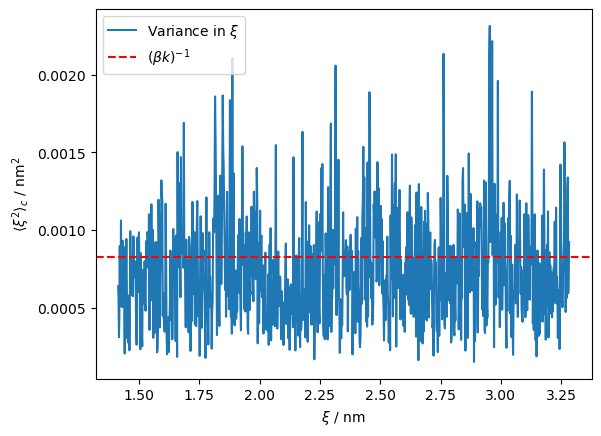

In [18]:
# Calculate variance in reaction coordinate value
var_in_rc_value = analysis.calculate_variance_of_reaction_coordinate(atom_coord_arrays, iguessmd_general_data['iguessmd_path'], every_nth_point=every_nth, include_end_point=False)

# Calculate 1 / (beta * k)
inv_beta_k = 1. / (analysis.calculate_beta_mol_kJ(iguessmd_general_data['temperature']) * iguessmd_general_data['iguessmd_force_constant'])

# Plot variance in reaction coordinate value
plt.plot(reduced_end_to_end_dist, var_in_rc_value, label=r"Variance in $\xi$")
plt.axhline(inv_beta_k, linestyle='dashed', color='red', label=r"$(\beta k)^{-1}$")
plt.xlabel(r"$\xi$ / nm")
plt.ylabel(r"$\langle \xi^{2} \rangle_{c}$ / nm$^{2}$")
plt.legend()
plt.show()